# 1. Import and Hardware setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset


import matplotlib.pyplot as plt

!pip install tqdm ipywidgets timm -q

from timm.models.layers import DropPath, to_2tuple, trunc_normal_
from tqdm.auto import tqdm

import math
import torch.utils.checkpoint as checkpoint

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
DATA_PATH = './Data'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# 2. Hyperparameter

In [3]:
IN_CHANNELS = 3
BATCH_SIZE = 128
NUM_CLASSES = 101
IMG_SIZE = 224

LR = 1e-3
EPOCHS = 150
SEED = 42

MODEL_NAME = "Swin-T"


# 3. Data Preparation

In [4]:
stats = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomRotation(15),
    transforms.RandomCrop(IMG_SIZE),
    transforms.TrivialAugmentWide(),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

In [5]:
import os
import random
import numpy as np

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

set_seed(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [6]:
# Download training data as dummy without transforms
dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

# Split the dummy data into two tmp subset
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
split_generator = torch.Generator().manual_seed(SEED)

train_tmp_subset, val_tmp_subset = random_split(
    dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = train_tmp_subset.indices
val_indices = val_tmp_subset.indices

# Create the subsets with correct transforms
train_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=train_transform
)
val_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=test_transform
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Download test dataset
test_dataset = datasets.Food101(
    root=DATA_PATH, split="test", download=True, transform=test_transform
)

100%|██████████| 5.00G/5.00G [00:23<00:00, 217MB/s] 


In [7]:
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_subset, 
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

# 4. Model Architecture

This implementation is from https://github.com/microsoft/Swin-Transformer/blob/main/models/swin_transformer.py

In [8]:
class WindowProcess(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input, B, H, W, C, shift_size, window_size):
        ctx.B = B
        ctx.H = H
        ctx.W = W 
        ctx.C = C 
        ctx.shift_size = shift_size
        ctx.window_size = window_size
        
        x = input.view(B, H, W, C)
        if shift_size != 0:
            x = torch.roll(x, shifts=(shift_size, shift_size), dims=(1, 2))
        
        x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
        windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
        return windows

    @staticmethod
    def backward(ctx, grad_in):
        B = ctx.B
        H = ctx.H
        W = ctx.W 
        C = ctx.C 
        shift_size = ctx.shift_size
        window_size = ctx.window_size
        
        grad_out = grad_in.view(B, H // window_size, W // window_size, window_size, window_size, C)
        grad_out = grad_out.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, C)
        
        if shift_size != 0:
            grad_out = torch.roll(grad_out, shifts=(-shift_size, -shift_size), dims=(1, 2))
            
        return grad_out.view(B, H, W, C), None, None, None, None, None, None


class WindowProcessReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input, B, H, W, C, shift_size, window_size):
        ctx.B = B
        ctx.H = H
        ctx.W = W 
        ctx.C = C 
        ctx.shift_size = shift_size
        ctx.window_size = window_size
        
        x = input.view(B, H // window_size, W // window_size, window_size, window_size, C)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, C)
        
        if shift_size != 0:
            x = torch.roll(x, shifts=(shift_size, shift_size), dims=(1, 2))
            
        return x

    @staticmethod
    def backward(ctx, grad_in):
        B = ctx.B
        H = ctx.H
        W = ctx.W 
        C = ctx.C 
        shift_size = ctx.shift_size
        window_size = ctx.window_size
        
        grad_out = grad_in.view(B, H, W, C)
        if shift_size != 0:
            grad_out = torch.roll(grad_out, shifts=(-shift_size, -shift_size), dims=(1, 2))
            
        grad_out = grad_out.view(B, H // window_size, window_size, W // window_size, window_size, C)
        grad_out = grad_out.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
        
        return grad_out, None, None, None, None, None, None


In [9]:
class MLP(nn.Module):
    def __init__(
        self,
        in_features,
        hidden_features=None,
        out_features=None,
        act_layer=nn.GELU,
        drop=0.0,
    ):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


def window_partition(x: torch.Tensor, window_size):
    """
    Args:
        x: (B, H, W, C)
        window_size (int)

    Returns:
        windows: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape

    # Reshapes the 4D input tensor into a 6D to isolate individual local windows of
    # size window_size x window_size
    # (B, H/M, M, W/M, M, C)
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)

    # Rearrange and flatten the tensor so that every local window is treated as an
    # independent sample in the batch dimension
    # (B, H/M, M, W/M, M, C) -> (B, H/M, W/H, M, M, C) -> ((B x H/M x W/H), M, M, C)
    windows = (
        x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    )
    return windows


def window_reverse(windows, window_size, H, W):
    """
    Args:
        windows: (num_windows*B, window_size, window_size, C)
        window_size (int)
        H (int): img height
        W (int): img width

    Return:
        x: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x: torch.Tensor = windows.view(
        B, H // window_size, W // window_size, window_size, window_size, -1
    )
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x


class WindowAttention(nn.Module):
    r"""W-MSA and SW-MSA

    Args:
        in_channels (int)
        window_size (tuple[int])
        num_heads (int)
        qkv_bias (bool, optional): If True, add a learnable bias to query, key, value. Default: True
        qk_scale
    """

    def __init__(
        self,
        in_channels,
        window_size,
        num_heads,
        qkv_bias=True,
        qk_scale=None,
        attn_drop=0.0,
        proj_drop=0.0,
    ):
        super().__init__()
        self.in_channels = in_channels
        self.dim = in_channels
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = in_channels // num_heads
        self.scale = qk_scale or head_dim**-0.5

        # define a parameter table of relative position bias
        self.relative_pos_bias_table = nn.Parameter(
            torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads)
        )  # (2*Wh-1)*(2*Ww-1)

        # get pair-wise relative position index for each token inside the window
        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid([coords_h, coords_w]))  # (2, Wh, Ww)
        coords_flatten = torch.flatten(coords, 1)  # (2, Wh*Ww)

        # Calculate the pairwise relative 2D coordinates between all tokens (patches)
        # within a local attention windows
        relative_coords = (
            coords_flatten[:, :, None] - coords_flatten[:, None, :]
        )  # (2, Wh*ww, Wh*Ww)
        # coords_flatten[:, :, None] -> reshapes the tensor to (2, Wh * Ww, 1)
        # coords_flatten[:, None, :] -> reshapes the tensor to (2, 1, Wh * Ww)
        # The "-" triggers PyTorch broadcasting to compute the difference for
        # every possible pair of tokens

        # Reshapes an reorganizes the memory layout of the relative coordinates tensor.
        relative_coords = relative_coords.permute(
            1, 2, 0
        ).contiguous()  # (Wh*Ww, Wh*Ww, 2)

        # Shift to start from 0, since distances can be negativ (from -(Wh - 1))
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1

        # Linearize the 2D index into 1D
        relative_coords[:, :, 0] += 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)

        # Saves the index map as non-linernable buffer. In the forward pass, this
        # index is used to gather the learnable bias parameters from relative_position_index
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(in_channels, in_channels * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(in_channels, in_channels)
        self.proj_drop = nn.Dropout(proj_drop)

        trunc_normal_(self.relative_pos_bias_table, std=0.02)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        """
        Args:
            x: input features with shape of (num_windows*B, N, C)
            mask: (0/-inf) mask with shape of (num_windows, Wh*Ww, Wh*Ww) or None
        """

        B_, N, C = x.shape

        # projects the input into Query, Key and Value tensors and
        # reshapes them for multi-head attention.
        # in (B_, N, C) -> (B_, N, C * 3) -> (3, B_, num_heads, N, head_dim)
        qkv = (
            self.qkv(x)
            .reshape(B_, N, 3, self.num_heads, C // self.num_heads)
            .permute(2, 0, 3, 1, 4)
        )

        q, k, v = (
            qkv[0],
            qkv[1],
            qkv[2],
        )

        # Scales the Query tensor by 1 / sqrt(head_dim)
        q = q * self.scale
        # Without scaling, the dot products between Q and K grow large
        # as head_dim increases. Large values push the Softmax into regions
        # with extremely small gradients (near 0 or 1), making training unstable.
        # Dividing by sqrt(head_dim) keeps the dot products in a numerically
        # stable range

        # Matrix multiplication of Q and K transposed
        attn = q @ k.transpose(-2, -1)
        # Q shape (B_, num_heads, N, head_dim)
        # K (B_, num_heads, N, head_dim) -> (B_, num_heads, head_dim, N)
        # --> attn (B_, num_heads, N, N)
        # Each entry attn[b, h, i, j] represents how much token i should
        # attend to token j under attention head h before Softmax normalization.

        # look up bias values from the table
        relativ_pos_bias = self.relative_pos_bias_table[
            self.relative_position_index.view(-1)
        ].view(
            self.window_size[0] * self.window_size[1],
            self.window_size[0] * self.window_size[1],
            -1,
        )

        # Reorder dimensions for attention (num_heads, Wh*Ww, Wh*Ww)
        relativ_pos_bias = relativ_pos_bias.permute(2, 0, 1).contiguous()

        # Add to attention scores
        attn = attn + relativ_pos_bias.unsqueeze(0)
        # .unsqueeze(0) adds a batch dimension (1, num_heads, Wh*Ww, Wh*Ww)
        # Broadcasting adds the same position bias across all batch elements.

        # applies the shifted window attention mask before Softmax.
        if mask is not None:
            # get the number of windows.
            nW = mask.shape[0]

            # Reshapes and adds mask
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(
                1
            ).unsqueeze(0)
            # attn (B_, num_heads, N, N) -> (B, nW, num_heads, N, N)
            # mask has shape (nW, N, N)
            # .unsqueeze(1) -> (nW, 1, N, N)
            # .unsqueeze(0) -> (1, nW, N, N)

            # Flatten back -> (B_, num_heads, N, N)
            attn = attn.view(-1, self.num_heads, N, N)

            # Applies softmax regardless of whether a mask was used.
            attn = self.softmax(attn)
            # The -100 values become approximately 0 after Softmax,
            # effectively blocking
        else:
            attn = self.softmax(attn)

        attn = self.attn_drop(attn)

        # Multiply Attention Weights by Values & Concatenate Heads
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        # atnn @ v: Computes a weighted sum of the Value vectors v
        # v (B_, num_heads, N, head_dim) @ attn (B_, num_heads, N, head_dim)

        # applies a linear layer to the concatenated head outputs.
        x = self.proj(x)
        # This allows the model to mix the features learned across the
        # different attention heads.

        # dropout
        x = self.proj_drop(x)
        return x

    # Defines a custom string representation for the WindowAttention
    # module when it is printed in PyTorch.
    def extr_repr(self) -> str:
        return f"dim={self.dim}, window_size={self.window_size}, num_heads={self.num_heads}"

    def flops(self, N):
        # calculate flops for 1 window with token length of N
        flops = 0
        flops += N * self.dim * 3 * self.dim
        flops += self.num_heads * N * (self.dim // self.num_heads) * N
        flops += self.num_heads * N * N * (self.dim // self.num_heads)
        flops += N * self.dim * self.dim
        return flops


class SwinTransformerBlock(nn.Module):
    """
    Args:
        dim (int): Number of input channels.
        input_resolution (tuple[int])
        num_heads (int): Number of attention heads.
        window_size (int)
        shift_size (int): Shift size for SW-MSA.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
        qkv_bias (bool, optional): If true, add a learnable bias to
        query, key, value. Default: True.
        qk_scale (float | None, optional): Override default qk scale
        of head_dim ** -0.5 if set.
        drop (float, optional) - default 0.0
        attn_drop (float, optional) - default: 0.0
        act_layer (nn.Module, optional) - default: nn.GELU
        norm_layer (nn.Module, optional) - default: nn.LayerNorm
        fused_window_process (bool, optional): If true, use one kernel
        to fused window shift & window partition for acceleration,
        similar for the reversed part. Default: False
    """

    def __init__(
        self,
        dim,
        input_resolution,
        num_heads,
        window_size=7,
        shift_size=0,
        mlp_ratio=4,
        qkv_bias=True,
        qk_scale=None,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        act_layer=nn.GELU,
        norm_layer=nn.LayerNorm,
        fused_window_process=False,
    ):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio

        # if window size is larger than input resolution, we don't partition window
        if min(self.input_resolution) <= self.window_size:
            self.shift_size = 0
            self.window_size = min(self.input_resolution)
        assert 0 <= self.shift_size < self.window_size, (
            "shift_size must be in 0-window_size"
        )

        self.norm1 = norm_layer(dim)
        self.attn = WindowAttention(
            dim,
            window_size=to_2tuple(self.window_size),
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            qk_scale=qk_scale,
            attn_drop=attn_drop,
            proj_drop=drop,
        )

        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            act_layer=act_layer,
            drop=drop,
        )

        # Calculates the shifted window attention mask for SW-MSA
        if self.shift_size > 0:
            H, W = self.input_resolution
            img_mask = torch.zeros((1, H, W, 1))

            # Segmenting the Image into 9 Sub-Regions
            h_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            w_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )

            # Labeling the Regions with IDs.
            # Creates an ID gird of size (1, H, W, 1). Every pixel inside the
            # same sub-region is assigned the same integer D (0 -> 8).
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1

            # Partitioning the Mask into Windows
            mask_windows = window_partition(img_mask, self.window_size)
            mask_windows = mask_windows.view(-1, self.window_size * self.window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(
                attn_mask != 0, float(-100.0)
            ).masked_fill(attn_mask == 0, float(0.0))
        else:
            attn_mask = None
        
        self.register_buffer("attn_mask", attn_mask)
        self.fused_window_process = fused_window_process
    
    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"
        
        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)
        
        # cyclic shift
        if self.shift_size > 0:
            if not self.fused_window_process:
                shifted_x = torch.roll(
                    x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2)
                )
                # partition windows
                x_windows = window_partition(
                    shifted_x, self.window_size
                )  # nW*B, window_size, window_size, C
            else:
                x_windows = WindowProcess.apply(
                    x, B, H, W, C, -self.shift_size, self.window_size
                )
        else:
            shifted_x = x
            # partition windows
            x_windows = window_partition(
                shifted_x, self.window_size
            )  # nW*B, window_size, window_size, C

        x_windows = x_windows.view(
            -1, self.window_size * self.window_size, C
        )  # nW*B, window_size*window_size, C

        # W-MSA/SW-MSA
        attn_windows = self.attn(
            x_windows, mask=self.attn_mask
        )  # nW*B, window_size*window_size, C

        # merge windows
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)

        # reverse cyclic shift
        if self.shift_size > 0:
            if not self.fused_window_process:
                shifted_x = window_reverse(
                    attn_windows, self.window_size, H, W
                )  # B H' W' C
                x = torch.roll(
                    shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2)
                )
            else:
                x = WindowProcessReverse.apply(
                    attn_windows, B, H, W, C, self.shift_size, self.window_size
                )
        else:
            shifted_x = window_reverse(
                attn_windows, self.window_size, H, W
            )  # B H' W' C
            x = shifted_x
        x = x.view(B, H * W, C)
        x = shortcut + self.drop_path(x)

        # FFN
        x = x + self.drop_path(self.mlp(self.norm2(x)))

        return x

    def extra_repr(self) -> str:
        return (
            f"dim={self.dim}, input_resolution={self.input_resolution}, num_heads={self.num_heads}, "
            f"window_size={self.window_size}, shift_size={self.shift_size}, mlp_ratio={self.mlp_ratio}"
        )

    def flops(self):
        flops = 0
        H, W = self.input_resolution
        # norm1
        flops += self.dim * H * W
        # W-MSA/SW-MSA
        nW = H * W / self.window_size / self.window_size
        flops += nW * self.attn.flops(self.window_size * self.window_size)
        # mlp
        flops += 2 * H * W * self.dim * self.dim * self.mlp_ratio
        # norm2
        flops += self.dim * H * W
        return flops


class PatchMerging(nn.Module):
    r"""Patch Merging Layer.

    Args:
        input_resolution (tuple[int]): Resolution of input feature.
        dim (int): Number of input channels.
        norm_layer (nn.Module, optional): Normalization layer.  Default: nn.LayerNorm
    """

    def __init__(self, input_resolution, dim, norm_layer=nn.LayerNorm):
        super().__init__()
        self.input_resolution = input_resolution
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x):
        """
        x: B, H*W, C
        """
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"
        assert H % 2 == 0 and W % 2 == 0, f"x size ({H}*{W}) are not even."

        x = x.view(B, H, W, C)

        x0 = x[:, 0::2, 0::2, :]  # B H/2 W/2 C
        x1 = x[:, 1::2, 0::2, :]  # B H/2 W/2 C
        x2 = x[:, 0::2, 1::2, :]  # B H/2 W/2 C
        x3 = x[:, 1::2, 1::2, :]  # B H/2 W/2 C
        x = torch.cat([x0, x1, x2, x3], -1)  # B H/2 W/2 4*C
        x = x.view(B, -1, 4 * C)  # B H/2*W/2 4*C

        x = self.norm(x)
        x = self.reduction(x)

        return x

    def extra_repr(self) -> str:
        return f"input_resolution={self.input_resolution}, dim={self.dim}"

    def flops(self):
        H, W = self.input_resolution
        flops = H * W * self.dim
        flops += (H // 2) * (W // 2) * 4 * self.dim * 2 * self.dim
        return flops


class BasicLayer(nn.Module):
    """A basic Swin Transformer layer for one stage.

    Args:
        dim (int): Number of input channels.
        input_resolution (tuple[int]): Input resolution.
        depth (int): Number of blocks.
        num_heads (int): Number of attention heads.
        window_size (int): Local window size.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
        qkv_bias (bool, optional): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float | tuple[float], optional): Stochastic depth rate. Default: 0.0
        norm_layer (nn.Module, optional): Normalization layer. Default: nn.LayerNorm
        downsample (nn.Module | None, optional): Downsample layer at the end of the layer. Default: None
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False.
        fused_window_process (bool, optional): If True, use one kernel to fused window shift & window partition for acceleration, similar for the reversed part. Default: False
    """

    def __init__(
        self,
        dim,
        input_resolution,
        depth,
        num_heads,
        window_size,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        norm_layer=nn.LayerNorm,
        downsample=None,
        use_checkpoint=False,
        fused_window_process=False,
    ):

        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.depth = depth
        self.use_checkpoint = use_checkpoint

        # build blocks
        self.blocks = nn.ModuleList(
            [
                SwinTransformerBlock(
                    dim=dim,
                    input_resolution=input_resolution,
                    num_heads=num_heads,
                    window_size=window_size,
                    shift_size=0 if (i % 2 == 0) else window_size // 2,
                    mlp_ratio=mlp_ratio,
                    qkv_bias=qkv_bias,
                    qk_scale=qk_scale,
                    drop=drop,
                    attn_drop=attn_drop,
                    drop_path=drop_path[i]
                    if isinstance(drop_path, list)
                    else drop_path,
                    norm_layer=norm_layer,
                    fused_window_process=fused_window_process,
                )
                for i in range(depth)
            ]
        )

        # patch merging layer
        if downsample is not None:
            self.downsample = downsample(
                input_resolution, dim=dim, norm_layer=norm_layer
            )
        else:
            self.downsample = None

    def forward(self, x):
        for blk in self.blocks:
            if self.use_checkpoint:
                x = checkpoint.checkpoint(blk, x)
            else:
                x = blk(x)
        if self.downsample is not None:
            x = self.downsample(x)
        return x

    def extra_repr(self) -> str:
        return f"dim={self.dim}, input_resolution={self.input_resolution}, depth={self.depth}"

    def flops(self):
        flops = 0
        for blk in self.blocks:
            flops += blk.flops()
        if self.downsample is not None:
            flops += self.downsample.flops()
        return flops


class PatchEmbed(nn.Module):
    r"""Image to Patch Embedding

    Args:
        img_size (int): Image size.  Default: 224.
        patch_size (int): Patch token size. Default: 4.
        in_chans (int): Number of input image channels. Default: 3.
        embed_dim (int): Number of linear projection output channels. Default: 96.
        norm_layer (nn.Module, optional): Normalization layer. Default: None
    """

    def __init__(
        self, img_size=224, patch_size=4, in_chans=3, embed_dim=96, norm_layer=None
    ):
        super().__init__()
        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        patches_resolution = [
            img_size[0] // patch_size[0],
            img_size[1] // patch_size[1],
        ]
        self.img_size = img_size
        self.patch_size = patch_size
        self.patches_resolution = patches_resolution
        self.num_patches = patches_resolution[0] * patches_resolution[1]

        self.in_chans = in_chans
        self.embed_dim = embed_dim

        self.proj = nn.Conv2d(
            in_chans, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        if norm_layer is not None:
            self.norm = norm_layer(embed_dim)
        else:
            self.norm = None

    def forward(self, x):
        B, C, H, W = x.shape
        # FIXME look at relaxing size constraints
        assert H == self.img_size[0] and W == self.img_size[1], (
            f"Input image size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]})."
        )
        x = self.proj(x).flatten(2).transpose(1, 2)  # B Ph*Pw C
        if self.norm is not None:
            x = self.norm(x)
        return x

    def flops(self):
        Ho, Wo = self.patches_resolution
        flops = (
            Ho
            * Wo
            * self.embed_dim
            * self.in_chans
            * (self.patch_size[0] * self.patch_size[1])
        )
        if self.norm is not None:
            flops += Ho * Wo * self.embed_dim
        return flops


class SwinTransformer(nn.Module):
    r"""Swin Transformer
        A PyTorch impl of : `Swin Transformer: Hierarchical Vision Transformer using Shifted Windows`  -
          https://arxiv.org/pdf/2103.14030

    Args:
        img_size (int | tuple(int)): Input image size. Default 224
        patch_size (int | tuple(int)): Patch size. Default: 4
        in_chans (int): Number of input image channels. Default: 3
        num_classes (int): Number of classes for classification head. Default: 1000
        embed_dim (int): Patch embedding dimension. Default: 96
        depths (tuple(int)): Depth of each Swin Transformer layer.
        num_heads (tuple(int)): Number of attention heads in different layers.
        window_size (int): Window size. Default: 7
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4
        qkv_bias (bool): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float): Override default qk scale of head_dim ** -0.5 if set. Default: None
        drop_rate (float): Dropout rate. Default: 0
        attn_drop_rate (float): Attention dropout rate. Default: 0
        drop_path_rate (float): Stochastic depth rate. Default: 0.1
        norm_layer (nn.Module): Normalization layer. Default: nn.LayerNorm.
        ape (bool): If True, add absolute position embedding to the patch embedding. Default: False
        patch_norm (bool): If True, add normalization after patch embedding. Default: True
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False
        fused_window_process (bool, optional): If True, use one kernel to fused window shift & window partition for acceleration, similar for the reversed part. Default: False
    """

    def __init__(
        self,
        img_size=224,
        patch_size=4,
        in_chans=3,
        num_classes=1000,
        embed_dim=96,
        depths=[2, 2, 6, 2],
        num_heads=[3, 6, 12, 24],
        window_size=7,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.1,
        norm_layer=nn.LayerNorm,
        ape=False,
        patch_norm=True,
        use_checkpoint=False,
        fused_window_process=False,
        **kwargs,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.num_layers = len(depths)
        self.embed_dim = embed_dim
        self.ape = ape
        self.patch_norm = patch_norm
        self.num_features = int(embed_dim * 2 ** (self.num_layers - 1))
        self.mlp_ratio = mlp_ratio

        # split image into non-overlapping patches
        self.patch_embed = PatchEmbed(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            norm_layer=norm_layer if self.patch_norm else None,
        )
        num_patches = self.patch_embed.num_patches
        patches_resolution = self.patch_embed.patches_resolution
        self.patches_resolution = patches_resolution

        # absolute position embedding
        if self.ape:
            self.absolute_pos_embed = nn.Parameter(
                torch.zeros(1, num_patches, embed_dim)
            )
            trunc_normal_(self.absolute_pos_embed, std=0.02)

        self.pos_drop = nn.Dropout(p=drop_rate)

        # stochastic depth
        dpr = [
            x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))
        ]  # stochastic depth decay rule

        # build layers
        self.layers = nn.ModuleList()
        for i_layer in range(self.num_layers):
            layer = BasicLayer(
                dim=int(embed_dim * 2**i_layer),
                input_resolution=(
                    patches_resolution[0] // (2**i_layer),
                    patches_resolution[1] // (2**i_layer),
                ),
                depth=depths[i_layer],
                num_heads=num_heads[i_layer],
                window_size=window_size,
                mlp_ratio=self.mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[sum(depths[:i_layer]) : sum(depths[: i_layer + 1])],
                norm_layer=norm_layer,
                downsample=PatchMerging if (i_layer < self.num_layers - 1) else None,
                use_checkpoint=use_checkpoint,
                fused_window_process=fused_window_process,
            )
            self.layers.append(layer)

        self.norm = norm_layer(self.num_features)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.head = (
            nn.Linear(self.num_features, num_classes)
            if num_classes > 0
            else nn.Identity()
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    @torch.jit.ignore
    def no_weight_decay(self):
        return {"absolute_pos_embed"}

    @torch.jit.ignore
    def no_weight_decay_keywords(self):
        return {"relative_position_bias_table"}

    def forward_features(self, x):
        x = self.patch_embed(x)
        if self.ape:
            x = x + self.absolute_pos_embed
        x = self.pos_drop(x)

        for layer in self.layers:
            x = layer(x)

        x = self.norm(x)  # B L C
        x = self.avgpool(x.transpose(1, 2))  # B C 1
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

    def flops(self):
        flops = 0
        flops += self.patch_embed.flops()
        for i, layer in enumerate(self.layers):
            flops += layer.flops()
        flops += (
            self.num_features
            * self.patches_resolution[0]
            * self.patches_resolution[1]
            // (2**self.num_layers)
        )
        flops += self.num_features * self.num_classes
        return flops


In [10]:


print(f"Using: {MODEL_NAME}")
model = SwinTransformer(
    img_size=IMG_SIZE,
    patch_size=4,
    in_chans=IN_CHANNELS,
    num_classes=NUM_CLASSES,
    embed_dim=96,
    depths=[2, 2, 6, 2],
    num_heads=[3, 6, 12, 24],
    window_size=7,
    mlp_ratio=4.0,
    qkv_bias=True,
    drop_rate=0.0,
    attn_drop_rate=0.0,
    drop_path_rate=0.1
).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

Using: Swin-T


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Total parameters: 27.60M


# 5. Training Preparation

In [11]:
class EarlyStopping:
    def __init__(
        self, patience=10, delta=0, verbose=False, save_path="best_checkpoint.pth"
    ):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path
        self.verbose = verbose

        self.early_stop = False
        self.counter = 0
        self.best_loss = None
    
    def __call__(self, model, val_loss):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # 2. If the loss didnt decrease as expect
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # 3. The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = (
            model.module.state_dict()
            if hasattr(model, "module")
            else model.state_dict()
        )
        torch.save(state_dict, self.save_path)

In [12]:
def sample_cutmix_box(batch_shape, mix_ration):
    """Generate a random CutMix box for NCHW tensors
    Return: y_min, y_max, x_min, x_max
    """
    img_height = batch_shape[2]
    img_width = batch_shape[3]
    
    cutmix_scale = np.sqrt(1.0 - mix_ration)
    cut_height = int(img_height * cutmix_scale)
    cut_width = int(img_width * cutmix_scale)
    
    # Center
    cx = np.random.randint(0, img_width)
    cy = np.random.randint(0, img_height)
    
    # Calculate the box coordinates
    x_min = np.clip(cx - cut_width // 2, 0, img_width)
    x_max = np.clip(cx + cut_width // 2, 0, img_width)
    y_min = np.clip(cy - cut_height // 2, 0, img_height)
    y_max = np.clip(cy + cut_height // 2, 0, img_height)
    
    return y_min, y_max, x_min, x_max

def apply_mixup_cutmix(x, y, p=0.5, alpha=1.0, cutmix_prob=0.5):
    """Returns:
        - x_mixed: The augmented image data 
        - y_a: The original labels of the current batch
        - y_b: The shuffled labels
        - lam: The mixing coefficient
        - use_mix: True or False
    """
    use_mix = np.random.rand() < p
    
    # 1. Not using mix
    if not use_mix:
        return x, y, y, 1.0, False
    
    # 2. Using mix
    # Create the mixing coefficient
    lam = float(np.random.beta(alpha, alpha))
    
    # Create a shuffled list of indices to decide which images
    # in the batch will be mixed together
    rand_index = torch.randperm(x.size(0), device=x.device)
    y_a, y_b = y, y[rand_index]
    
    # CutMix
    if np.random.rand() < cutmix_prob:
        x = x.clone()
        
        # Get the box coordinates
        y_min, y_max, x_min, x_max = sample_cutmix_box(x.size(), lam)
        
        # Put the other image in the box
        x[:, :, y_min:y_max, x_min:x_max] = x[rand_index, :, y_min:y_max, x_min:x_max]
        
        # Recalculate new lamda coefficient
        lam = 1.0 - ((y_max - y_min) * (x_max - x_min) / (x.size(-2) * x.size(-1)))
    # MixUp
    else:
        x = lam * x + (1.0 - lam) * x[rand_index, :]
    return x, y_a, y_b, lam, True

In [13]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer=optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    div_factor=10,
    final_div_factor=100,
)

# Scaler for using AMP - Mixed Precision
scaler = torch.amp.GradScaler(device)

In [14]:
def train(model, loader, criterion, optimizer, scaler, scheduler):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    loop = tqdm(loader, desc="Training", leave=False)

    for x, y in loop:
        # Move samples and labels to device
        x, y = x.to(device), y.to(device)

        # Zero out the gradients of last batch
        optimizer.zero_grad(set_to_none=True)

        # Using CutMix/MixUp
        x, y_a, y_b, lam, use_mix = apply_mixup_cutmix(
            x, y, p=0.5, alpha=1.0, cutmix_prob=0.5
        )

        with torch.amp.autocast(device_type=device.type):
            # Get prediction
            out = model(x)

            # Get the loss
            loss = (
                lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                if use_mix
                else criterion(out, y)
            )

        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()

        # Unscale and clip the gradients
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update the paramters
        scaler.step(optimizer)

        # Update the scaler
        scaler.update()

        # Update lr after each batch because of using OneCycleLR
        scheduler.step()

        train_loss += loss.detach() * x.size(0)
        if use_mix:
            train_acc += (
                lam * (out.argmax(1) == y_a).float()
                + (1 - lam) * (out.argmax(1) == y_b).float()
            ).sum()
        else:
            train_acc += (out.argmax(1) == y).sum()
    return train_loss.item() / len(loader.dataset), train_acc.item() / len(
        loader.dataset
    )


def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast(device_type=device.type):
                out = model(x)
                loss = criterion(out, y)
            val_loss += loss.detach() * x.size(0)
            val_acc += (out.argmax(1) == y).sum()
    return val_loss.item() / len(loader.dataset), val_acc.item() / len(loader.dataset)


def test(model, loader):
    model.eval()
    test_acc = 0.0
    loop = tqdm(loader, desc="Testing", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)
            test_acc += (out.argmax(1) == y).sum()
    return test_acc / len(loader.dataset)

# 6. Train

In [15]:
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
early_stopping = EarlyStopping(patience=10, delta=0.01)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, " +
          f"train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")
    
    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early Stopping")
        break

best_model = model.module if hasattr(model, 'module') else model
best_model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))
test_acc = test(best_model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 1/150: train_loss: 4.5219, val_loss: 4.2969, train_acc: 0.0303, val_acc: 0.0606


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

...

Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 16/150: train_loss: 4.2485, val_loss: 4.0278, train_acc: 0.0862, val_acc: 0.1072
Early Stopping counter: 10 out of 10
Early Stopping


Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Final test accuracy: 0.2374


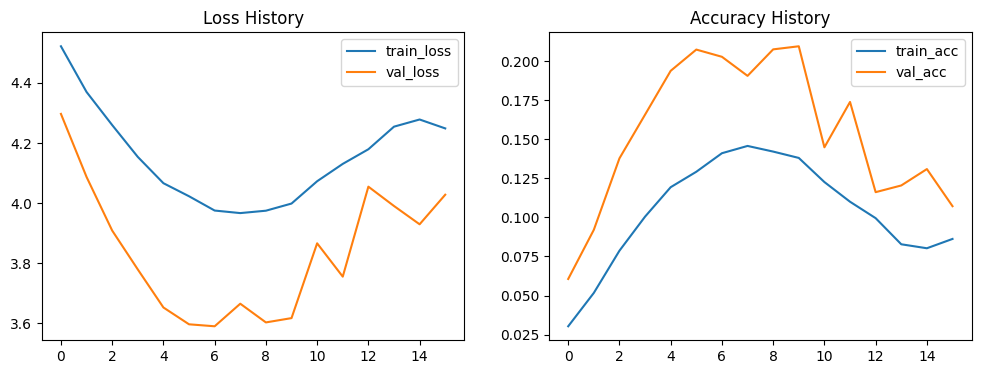

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='train_acc')
plt.plot(val_accuracies, label='val_acc')
plt.title('Accuracy History')
plt.legend()

# 7. GradCAM

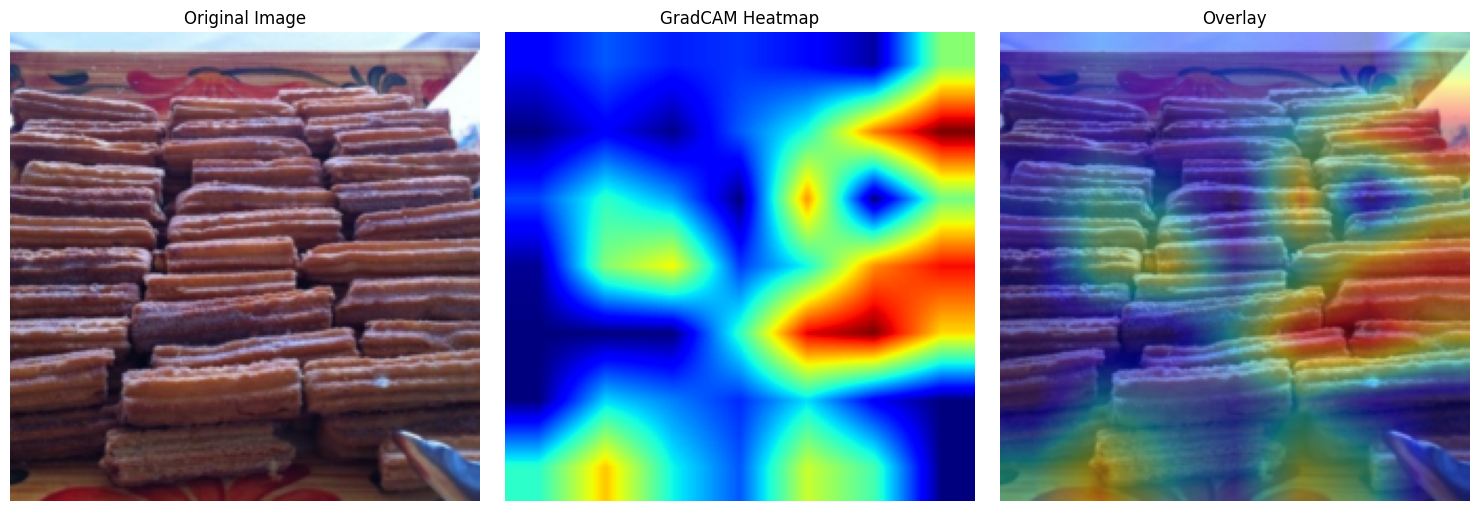

In [17]:
import torch.nn.functional as F
import math
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks to capture the features and gradients
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        activation = output
        if len(activation.shape) == 3:
            # Swin Transformer shape: (B, L, C)
            B, L, C = activation.shape
            H = int(math.sqrt(L))
            activation = activation.transpose(1, 2).view(B, C, H, H)
        self.activations = activation

    def save_gradient(self, module, grad_input, grad_output):
        grad = grad_output[0]
        if len(grad.shape) == 3:
            # Swin Transformer shape: (B, L, C)
            B, L, C = grad.shape
            H = int(math.sqrt(L))
            grad = grad.transpose(1, 2).view(B, C, H, H)
        self.gradients = grad

    def generate_heatmap(self, input_image, target_class=None):
        self.model.eval()
        
        # 1. Forward pass
        model_output = self.model(input_image)
        
        # If no target class is specified, use the predicted class
        if target_class is None:
            target_class = model_output.argmax(dim=1).item()
            
        # 2. Backward pass for the target class
        self.model.zero_grad()
        target_score = model_output[0, target_class]
        target_score.backward()

        # 3. Calculate weights using Global Average Pooling on the gradients
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)

        # 4. Multiply weights by activations to get the raw heatmap
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)

        # 5. Apply ReLU (we only care about features that have a positive influence)
        cam = F.relu(cam)
        
        # 6. Resize the heatmap to match the original image dimensions
        cam = F.interpolate(
            cam, 
            size=(input_image.shape[2], input_image.shape[3]), 
            mode='bilinear', 
            align_corners=False
        )
        
        # 7. Normalize the heatmap to be between 0 and 1
        cam = cam.squeeze().cpu().detach().numpy()
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8)
        
        return cam

def plot_gradcam(image_tensor, cam_heatmap):
    # Convert tensor image to numpy format (Height, Width, Channels)
    img = image_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    
    # Denormalize the image using your exact dataset stats
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    # Create the color heatmap using matplotlib's jet colormap
    jet = plt.get_cmap('jet')
    heatmap_colored = jet(cam_heatmap)[..., :3] # Remove alpha channel
    
    # Create the final overlay
    overlay = heatmap_colored * 0.4 + img * 0.6
    overlay = np.clip(overlay, 0, 1)

    # Plot the results side-by-side
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    ax[1].imshow(cam_heatmap, cmap='jet')
    ax[1].set_title('GradCAM Heatmap')
    ax[1].axis('off')
    
    ax[2].imshow(overlay)
    ax[2].set_title('Overlay')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# Example Usage with Swin Transformer
# ==========================================

# Step 1: Define the target layer
# Use the last block in the last layer for GradCAM.
target_layer = model.layers[-1].blocks[-1].norm2

# Step 2: Initialize GradCAM
grad_cam = GradCAM(model, target_layer)

# Step 3: Get a sample image from the test loader
sample_images, sample_labels = next(iter(test_loader))
sample_image = sample_images[0:1].to(device) # Keep batch dimension of 1

# Step 4: Generate and plot the heatmap
heatmap = grad_cam.generate_heatmap(sample_image)
plot_gradcam(sample_image, heatmap)
